In [2]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

In [3]:
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", "{:.4f}".format)

In [4]:
DATA_DIR   = Path(".")           
OUTPUT_DIR = Path("outputs/eda/")  
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
TARGET       = "TARGET"

In [5]:
def save_fig(name: str, tight=True):
    path = OUTPUT_DIR / f"{name}.png"
    if tight:
        plt.tight_layout()
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()

In [6]:
def missing_report(df: pd.DataFrame, label: str = "") -> pd.DataFrame:
    """Return a DataFrame with missing-value counts and percentages."""
    mis = df.isnull().sum()
    mis_pct = mis / len(df) * 100
    report = (
        pd.DataFrame({"missing_count": mis, "missing_pct": mis_pct})
        .query("missing_count > 0")
        .sort_values("missing_pct", ascending=False)
    )
    if label:
        print(f"\n{'─'*60}")
        print(f"  Missing values — {label}  ({len(df):,} rows, {df.shape[1]} cols)")
        print(f"  Columns with nulls: {len(report)} / {df.shape[1]}")
        print(report.head(20).to_string())
    return report

In [7]:
def reduce_mem_usage(df: pd.DataFrame) -> pd.DataFrame:
    """Downcast numeric columns to save RAM."""
    for col in df.select_dtypes(include=["int64", "float64"]).columns:
        col_min, col_max = df[col].min(), df[col].max()
        if df[col].dtype == "int64":
            if col_min >= np.iinfo(np.int8).min and col_max <= np.iinfo(np.int8).max:
                df[col] = df[col].astype(np.int8)
            elif col_min >= np.iinfo(np.int16).min and col_max <= np.iinfo(np.int16).max:
                df[col] = df[col].astype(np.int16)
            elif col_min >= np.iinfo(np.int32).min and col_max <= np.iinfo(np.int32).max:
                df[col] = df[col].astype(np.int32)
        else:
            df[col] = pd.to_numeric(df[col], downcast="float")
    return df

In [8]:
print("  1. LOADING DATA")


train = pd.read_csv(DATA_DIR / "application_train.csv")
test  = pd.read_csv(DATA_DIR / "application_test.csv")

print(f"  train shape : {train.shape}")
print(f"  test  shape : {test.shape}")
print(f"  Target distribution:\n{train[TARGET].value_counts(normalize=True).round(4)}")

  1. LOADING DATA
  train shape : (307511, 122)
  test  shape : (48744, 121)
  Target distribution:
TARGET
0   0.9193
1   0.0807
Name: proportion, dtype: float64


  2. EDA — APPLICATION_TRAIN


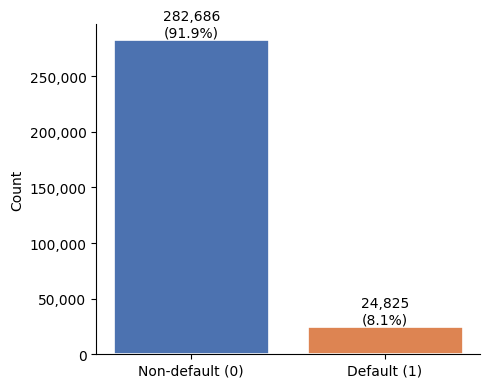

In [9]:
print("  2. EDA — APPLICATION_TRAIN")

fig, ax = plt.subplots(figsize=(5, 4))
counts = train[TARGET].value_counts()
bars = ax.bar(["Non-default (0)", "Default (1)"], counts.values,
              color=["#4C72B0", "#DD8452"], edgecolor="white", linewidth=1.2)
for bar, cnt in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f"{cnt:,}\n({cnt/len(train)*100:.1f}%)", ha="center", va="bottom", fontsize=10)
ax.set_ylabel("Count")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
sns.despine()
save_fig("01_target_distribution")


────────────────────────────────────────────────────────────
  Missing values — application_train  (307,511 rows, 122 cols)
  Columns with nulls: 67 / 122
                          missing_count  missing_pct
COMMONAREA_MEDI                  214865      69.8723
COMMONAREA_MODE                  214865      69.8723
COMMONAREA_AVG                   214865      69.8723
NONLIVINGAPARTMENTS_MODE         213514      69.4330
NONLIVINGAPARTMENTS_MEDI         213514      69.4330
NONLIVINGAPARTMENTS_AVG          213514      69.4330
FONDKAPREMONT_MODE               210295      68.3862
LIVINGAPARTMENTS_AVG             210199      68.3550
LIVINGAPARTMENTS_MEDI            210199      68.3550
LIVINGAPARTMENTS_MODE            210199      68.3550
FLOORSMIN_MEDI                   208642      67.8486
FLOORSMIN_MODE                   208642      67.8486
FLOORSMIN_AVG                    208642      67.8486
YEARS_BUILD_MODE                 204488      66.4978
YEARS_BUILD_MEDI                 204488      66.4

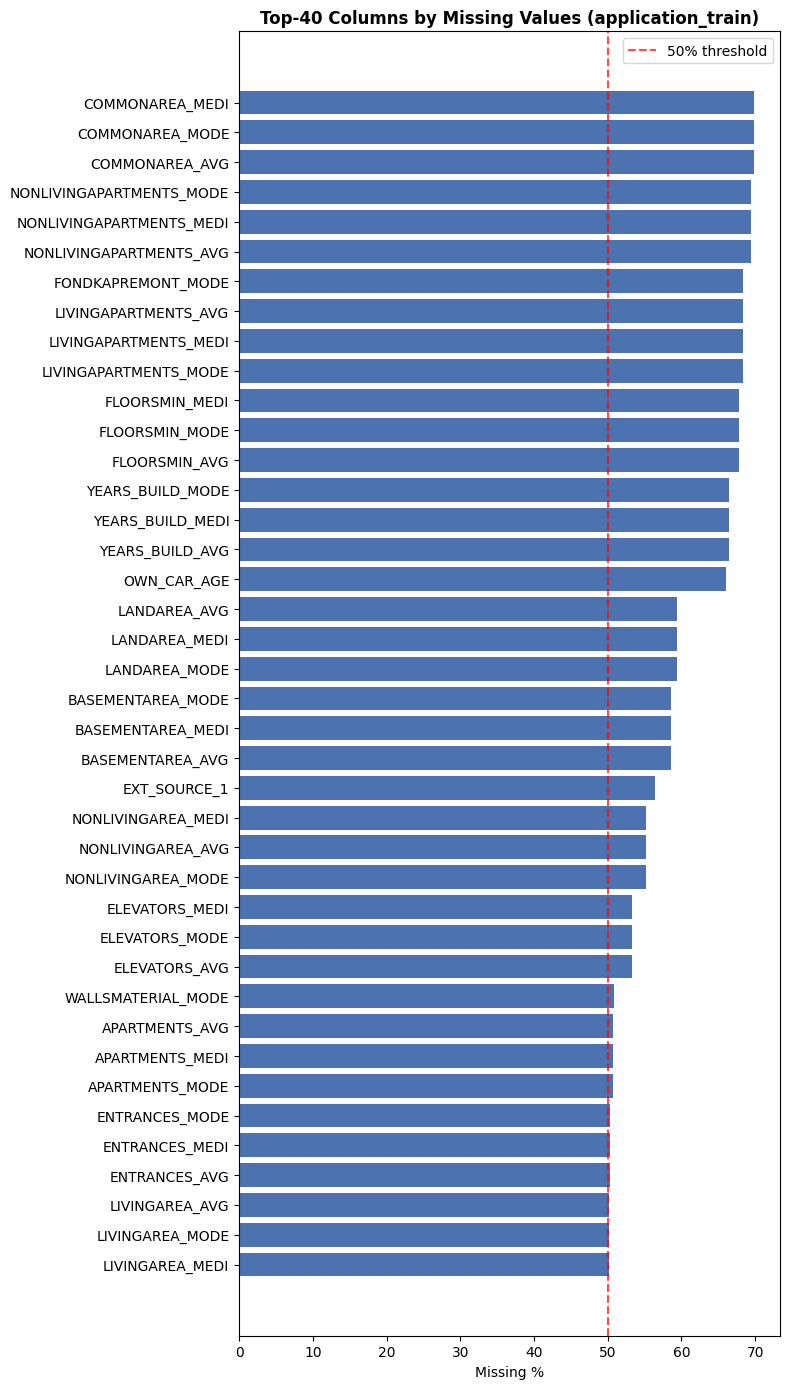

In [10]:
mis = missing_report(train, "application_train")

top_mis = mis.head(40)
fig, ax = plt.subplots(figsize=(8, max(4, len(top_mis)*0.35)))
ax.barh(top_mis.index[::-1], top_mis["missing_pct"][::-1], color="#4C72B0")
ax.set_xlabel("Missing %")
ax.set_title("Top-40 Columns by Missing Values (application_train)", fontweight="bold")
ax.axvline(50, color="red", linestyle="--", alpha=0.7, label="50% threshold")
ax.legend()
save_fig("02_missing_values_train")

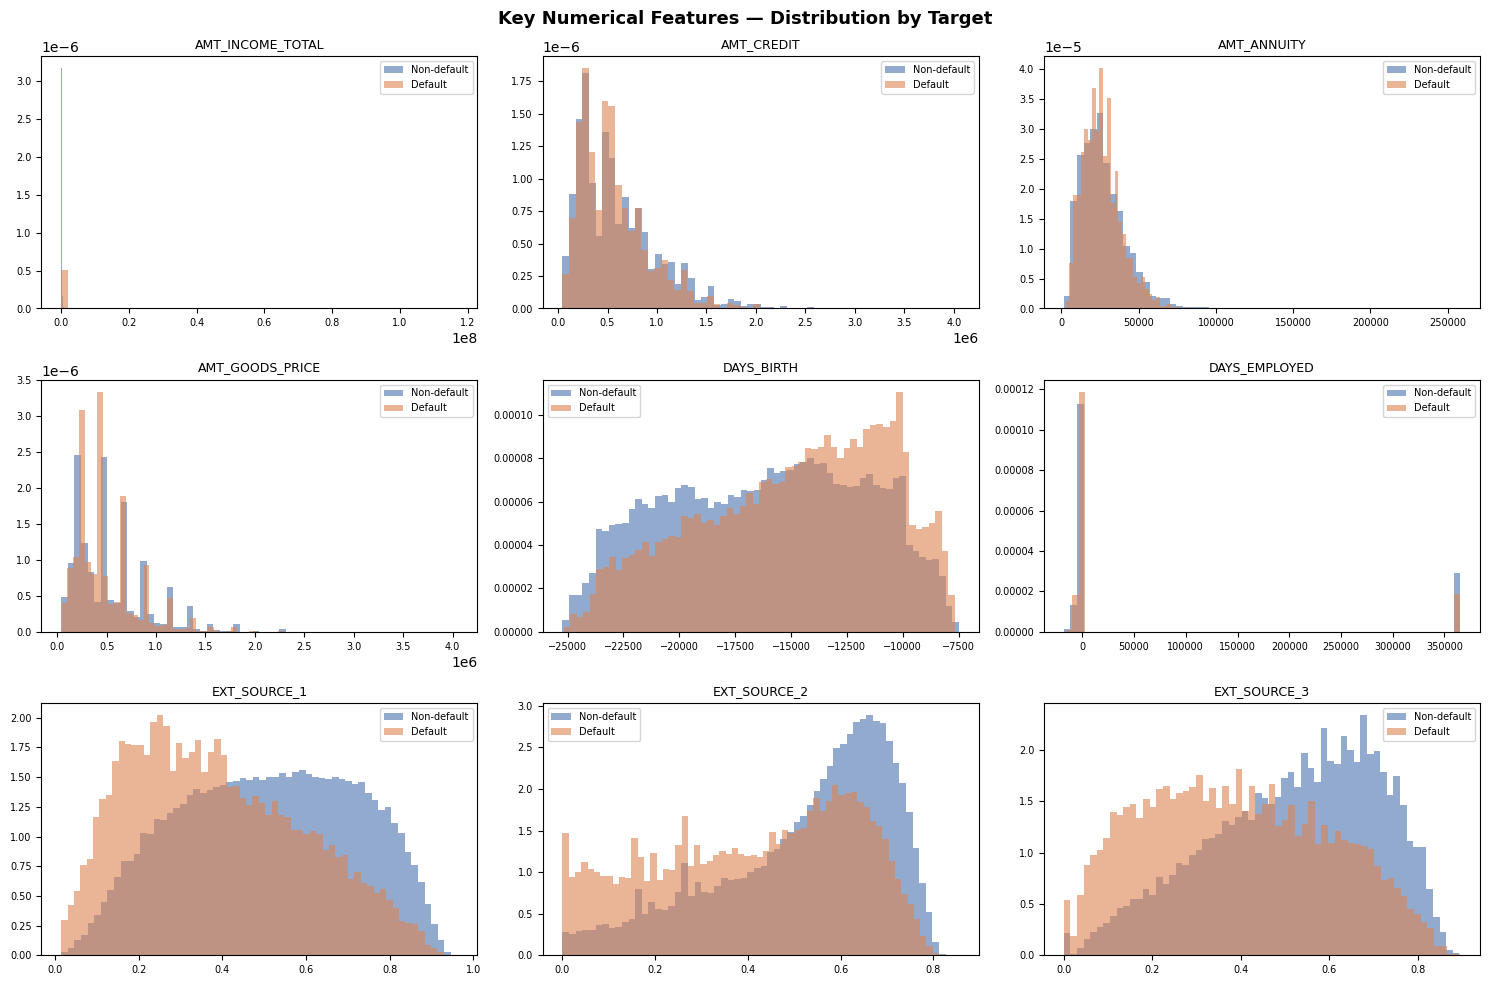

In [11]:
num_features = [
    "AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY", "AMT_GOODS_PRICE",
    "DAYS_BIRTH", "DAYS_EMPLOYED", "EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3",
]
num_features = [c for c in num_features if c in train.columns]

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()
for i, feat in enumerate(num_features):
    ax = axes[i]
    data_0 = train.loc[train[TARGET] == 0, feat].dropna()
    data_1 = train.loc[train[TARGET] == 1, feat].dropna()
    ax.hist(data_0, bins=60, alpha=0.6, color="#4C72B0", label="Non-default", density=True)
    ax.hist(data_1, bins=60, alpha=0.6, color="#DD8452", label="Default", density=True)
    ax.set_title(feat, fontsize=9)
    ax.legend(fontsize=7)
    ax.tick_params(labelsize=7)
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
fig.suptitle("Key Numerical Features — Distribution by Target", fontsize=13, fontweight="bold")
save_fig("03_numerical_distributions")

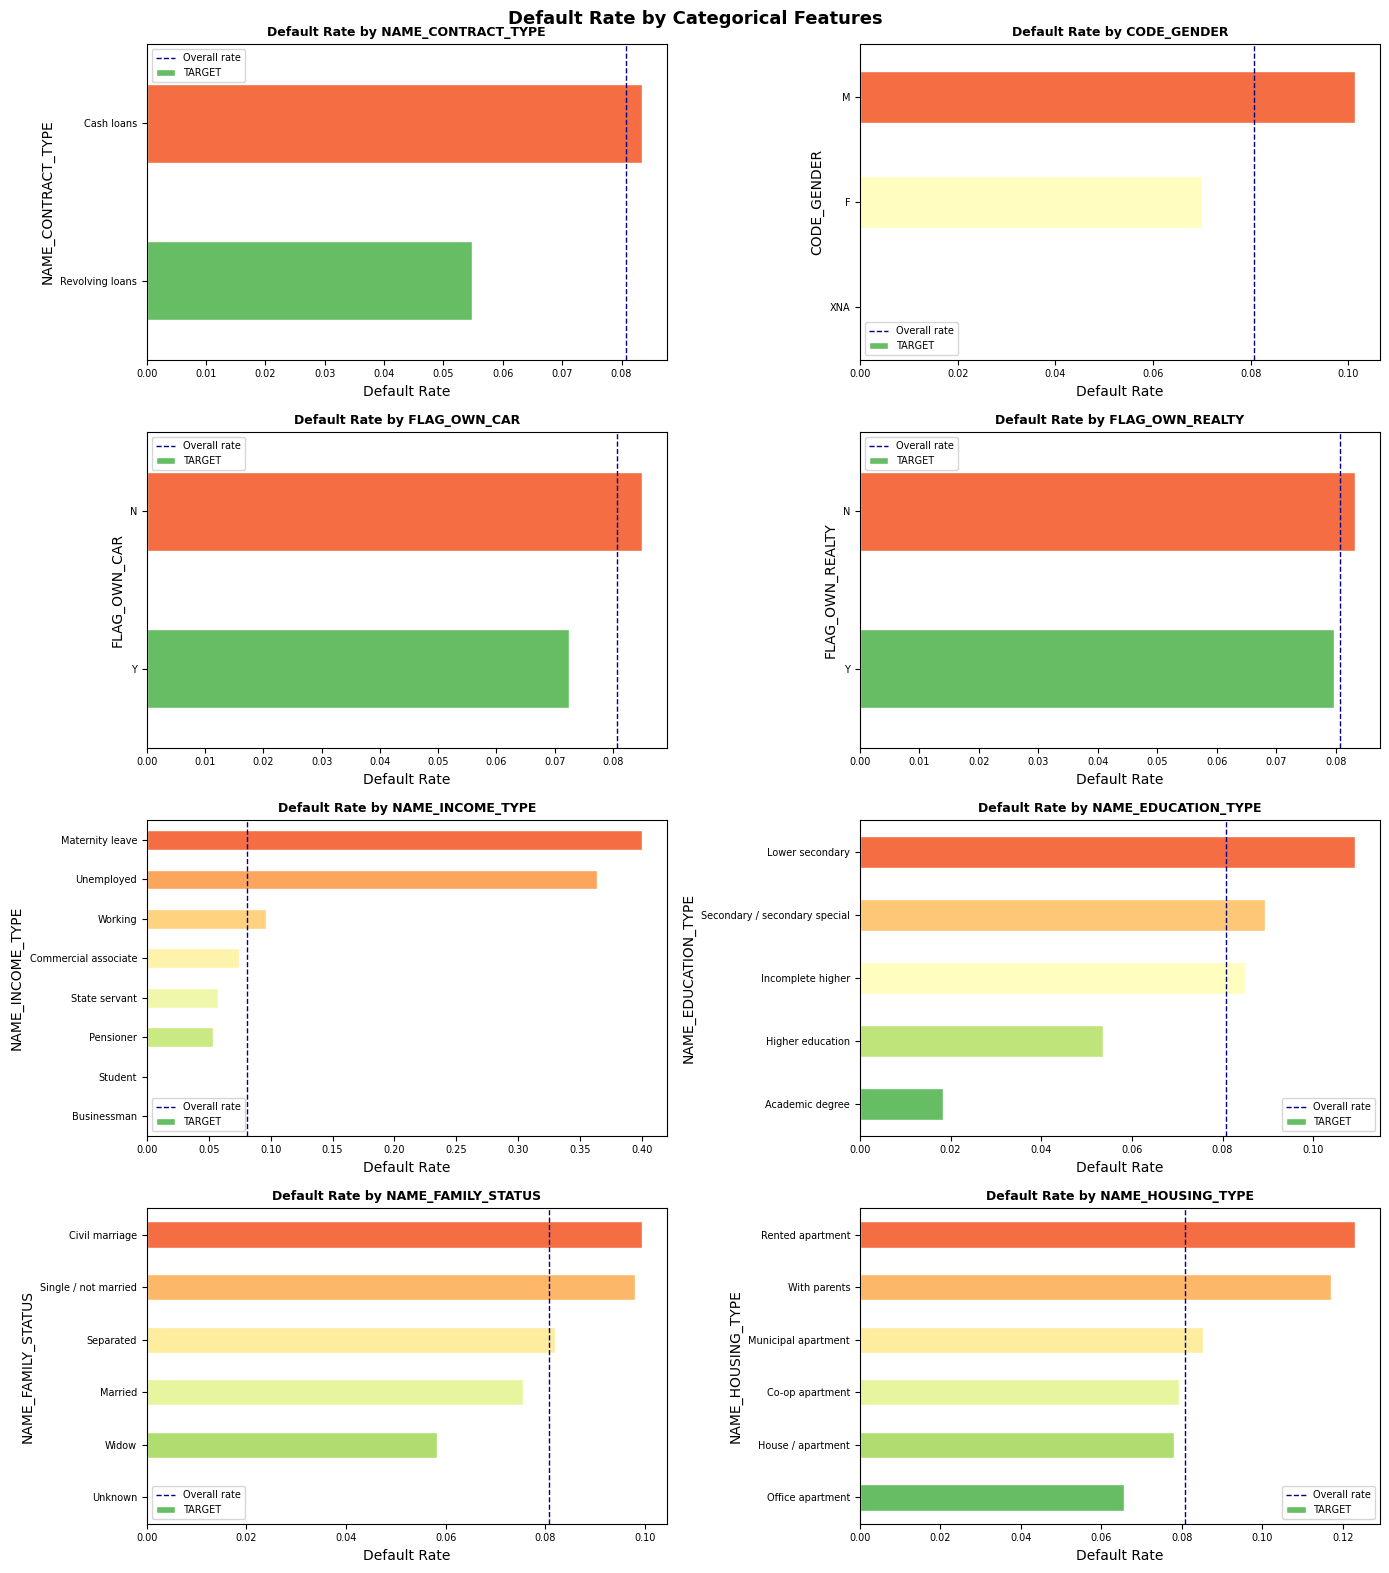

In [12]:
cat_features = [
    "NAME_CONTRACT_TYPE", "CODE_GENDER", "FLAG_OWN_CAR", "FLAG_OWN_REALTY",
    "NAME_INCOME_TYPE", "NAME_EDUCATION_TYPE", "NAME_FAMILY_STATUS",
    "NAME_HOUSING_TYPE",
]
cat_features = [c for c in cat_features if c in train.columns]

fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()
for i, feat in enumerate(cat_features):
    ax = axes[i]
    rate = train.groupby(feat)[TARGET].mean().sort_values(ascending=True)
    colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(rate)))
    rate.plot(kind="barh", ax=ax, color=colors, edgecolor="white")
    ax.set_title(f"Default Rate by {feat}", fontsize=9, fontweight="bold")
    ax.set_xlabel("Default Rate")
    ax.axvline(train[TARGET].mean(), color="navy", linestyle="--",
               linewidth=1, label="Overall rate")
    ax.legend(fontsize=7)
    ax.tick_params(labelsize=7)
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
fig.suptitle("Default Rate by Categorical Features", fontsize=13, fontweight="bold")
save_fig("04_categorical_default_rates")

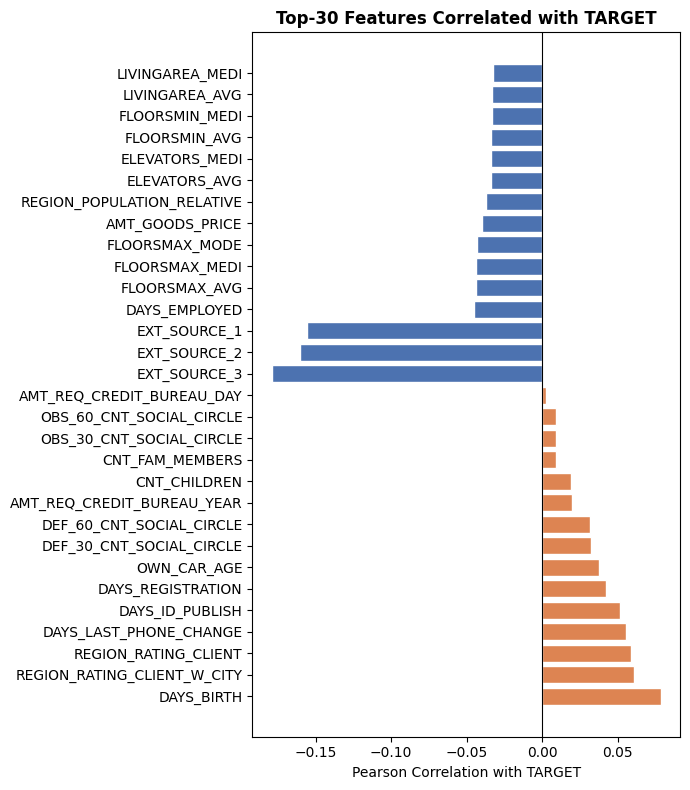

In [13]:
corr_cols = [c for c in train.columns
             if train[c].dtype in [np.float64, np.float32, np.int64, np.int32, np.int8, np.int16]
             and train[c].nunique() > 2]
corr_df = train[corr_cols + [TARGET]].corr()[[TARGET]].drop(TARGET)
top_pos = corr_df.nlargest(15, TARGET)
top_neg = corr_df.nsmallest(15, TARGET)
top_corr = pd.concat([top_pos, top_neg])

fig, ax = plt.subplots(figsize=(7, 8))
colors = ["#DD8452" if v > 0 else "#4C72B0" for v in top_corr[TARGET]]
ax.barh(top_corr.index, top_corr[TARGET], color=colors, edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Top-30 Features Correlated with TARGET", fontweight="bold")
ax.set_xlabel("Pearson Correlation with TARGET")
save_fig("05_correlation_with_target")

In [14]:
print("  3. FEATURE ENGINEERING — AUXILIARY TABLES")


def agg_bureau(data_dir: Path) -> pd.DataFrame:
    """Aggregate bureau.csv + bureau_balance.csv → one row per SK_ID_CURR."""
    print("  [bureau] loading...")
    bur = pd.read_csv(data_dir / "bureau.csv")
    bur_bal = pd.read_csv(data_dir / "bureau_balance.csv")

    # bureau_balance → aggregate to SK_ID_BUREAU level
    bal_agg = bur_bal.groupby("SK_ID_BUREAU").agg(
        bureau_bal_dpd_mean   = ("STATUS", lambda x: (x.isin(["1","2","3","4","5"])).mean()),
        bureau_bal_months_cnt = ("MONTHS_BALANCE", "count"),
    ).reset_index()

    bur = bur.merge(bal_agg, on="SK_ID_BUREAU", how="left")

    # bureau → aggregate to SK_ID_CURR level
    agg_dict = {
        "DAYS_CREDIT"            : ["min", "max", "mean"],
        "CREDIT_DAY_OVERDUE"     : ["max", "mean"],
        "DAYS_CREDIT_ENDDATE"    : ["max", "mean"],
        "AMT_CREDIT_SUM"         : ["sum", "mean"],
        "AMT_CREDIT_SUM_DEBT"    : ["sum", "mean"],
        "AMT_CREDIT_SUM_OVERDUE" : ["sum"],
        "CNT_CREDIT_PROLONG"     : ["sum"],
        "bureau_bal_dpd_mean"    : ["mean", "max"],
        "bureau_bal_months_cnt"  : ["sum"],
    }
    bur_agg = bur.groupby("SK_ID_CURR").agg(agg_dict)
    bur_agg.columns = ["BURO_" + "_".join(c).upper() for c in bur_agg.columns]

    # Count active vs closed credits
    status_counts = (
        bur.groupby(["SK_ID_CURR", "CREDIT_ACTIVE"])
           .size().unstack(fill_value=0)
           .add_prefix("BURO_CREDIT_ACTIVE_")
    )
    bur_agg = bur_agg.join(status_counts)
    bur_agg["BURO_COUNT"] = bur.groupby("SK_ID_CURR").size()
    print(f"  [bureau] agg shape: {bur_agg.shape}")
    return bur_agg.reset_index()

  3. FEATURE ENGINEERING — AUXILIARY TABLES


In [15]:
def agg_previous_application(data_dir: Path) -> pd.DataFrame:
    """Aggregate previous_application.csv → one row per SK_ID_CURR."""
    print("  [previous_application] loading...")
    prev = pd.read_csv(data_dir / "previous_application.csv")
    # Replace 365243 (infinity sentinel for DAYS columns)
    days_cols = [c for c in prev.columns if "DAYS" in c]
    prev[days_cols] = prev[days_cols].replace(365243, np.nan)

    agg_dict = {
        "AMT_ANNUITY"             : ["min", "max", "mean"],
        "AMT_APPLICATION"         : ["min", "max", "mean"],
        "AMT_CREDIT"              : ["min", "max", "mean"],
        "AMT_DOWN_PAYMENT"        : ["mean"],
        "DAYS_DECISION"           : ["min", "max", "mean"],
        "CNT_PAYMENT"             : ["sum", "mean"],
        "DAYS_FIRST_DRAWING"      : ["min"],
        "DAYS_LAST_DUE"           : ["max"],
    }
    prev_agg = prev.groupby("SK_ID_CURR").agg(agg_dict)
    prev_agg.columns = ["PREV_" + "_".join(c).upper() for c in prev_agg.columns]
    prev_agg["PREV_COUNT"] = prev.groupby("SK_ID_CURR").size()

    # Approved vs refused rates
    contract_status = (
        prev.groupby(["SK_ID_CURR", "NAME_CONTRACT_STATUS"])
            .size().unstack(fill_value=0)
            .add_prefix("PREV_CONTRACT_")
    )
    prev_agg = prev_agg.join(contract_status)
    print(f"  [previous_application] agg shape: {prev_agg.shape}")
    return prev_agg.reset_index()


In [16]:
def agg_pos_cash(data_dir: Path) -> pd.DataFrame:
    """Aggregate POS_CASH_balance.csv → one row per SK_ID_CURR."""
    print("  [POS_CASH] loading...")
    pos = pd.read_csv(data_dir / "POS_CASH_balance.csv")
    agg_dict = {
        "MONTHS_BALANCE"    : ["min", "max", "size"],
        "SK_DPD"            : ["max", "mean"],
        "SK_DPD_DEF"        : ["max", "mean"],
        "CNT_INSTALMENT"    : ["max"],
        "CNT_INSTALMENT_FUTURE": ["max", "mean"],
    }
    pos_agg = pos.groupby("SK_ID_CURR").agg(agg_dict)
    pos_agg.columns = ["POS_" + "_".join(map(str, c)).upper() for c in pos_agg.columns]
    print(f"  [POS_CASH] agg shape: {pos_agg.shape}")
    return pos_agg.reset_index()


In [17]:
def agg_installments(data_dir: Path) -> pd.DataFrame:
    """Aggregate installments_payments.csv → one row per SK_ID_CURR."""
    print("  [installments] loading...")
    ins = pd.read_csv(data_dir / "installments_payments.csv")
    ins["PAYMENT_DIFF"]    = ins["AMT_PAYMENT"]  - ins["AMT_INSTALMENT"]
    ins["DAYS_PAST_DUE"]   = ins["DAYS_ENTRY_PAYMENT"] - ins["DAYS_INSTALMENT"]
    ins["DAYS_BEFORE_DUE"] = ins["DAYS_INSTALMENT"] - ins["DAYS_ENTRY_PAYMENT"]
    ins["DAYS_PAST_DUE"]   = ins["DAYS_PAST_DUE"].clip(lower=0)
    ins["DAYS_BEFORE_DUE"] = ins["DAYS_BEFORE_DUE"].clip(lower=0)

    agg_dict = {
        "NUM_INSTALMENT_VERSION": ["nunique"],
        "DAYS_INSTALMENT"       : ["min", "max"],
        "DAYS_ENTRY_PAYMENT"    : ["min", "max"],
        "AMT_INSTALMENT"        : ["mean", "sum"],
        "AMT_PAYMENT"           : ["mean", "sum"],
        "PAYMENT_DIFF"          : ["mean", "min", "max"],
        "DAYS_PAST_DUE"         : ["mean", "max", "sum"],
        "DAYS_BEFORE_DUE"       : ["mean", "max"],
    }
    ins_agg = ins.groupby("SK_ID_CURR").agg(agg_dict)
    ins_agg.columns = ["INS_" + "_".join(map(str, c)).upper() for c in ins_agg.columns]
    ins_agg["INS_COUNT"] = ins.groupby("SK_ID_CURR").size()
    print(f"  [installments] agg shape: {ins_agg.shape}")
    return ins_agg.reset_index()


In [18]:
def agg_credit_card(data_dir: Path) -> pd.DataFrame:
    """Aggregate credit_card_balance.csv → one row per SK_ID_CURR."""
    print("  [credit_card] loading...")
    cc = pd.read_csv(data_dir / "credit_card_balance.csv")
    cc["UTILIZATION"] = cc["AMT_BALANCE"] / (cc["AMT_CREDIT_LIMIT_ACTUAL"] + 1)

    agg_dict = {
        "MONTHS_BALANCE"    : ["min", "max", "size"],
        "AMT_BALANCE"       : ["max", "mean"],
        "AMT_CREDIT_LIMIT_ACTUAL": ["max", "mean"],
        "AMT_DRAWINGS_CURRENT"   : ["sum", "mean"],
        "AMT_PAYMENT_CURRENT"    : ["sum", "mean"],
        "SK_DPD"            : ["max", "mean"],
        "SK_DPD_DEF"        : ["max", "mean"],
        "UTILIZATION"       : ["mean", "max"],
    }
    cc_agg = cc.groupby("SK_ID_CURR").agg(agg_dict)
    cc_agg.columns = ["CC_" + "_".join(map(str, c)).upper() for c in cc_agg.columns]
    print(f"  [credit_card] agg shape: {cc_agg.shape}")
    return cc_agg.reset_index()

In [19]:
tables_to_merge = []

if (DATA_DIR / "bureau.csv").exists():
    tables_to_merge.append(agg_bureau(DATA_DIR))

if (DATA_DIR / "previous_application.csv").exists():
    tables_to_merge.append(agg_previous_application(DATA_DIR))

if (DATA_DIR / "POS_CASH_balance.csv").exists():
    tables_to_merge.append(agg_pos_cash(DATA_DIR))

if (DATA_DIR / "installments_payments.csv").exists():
    tables_to_merge.append(agg_installments(DATA_DIR))

if (DATA_DIR / "credit_card_balance.csv").exists():
    tables_to_merge.append(agg_credit_card(DATA_DIR))


def merge_all(main_df: pd.DataFrame, agg_tables: list) -> pd.DataFrame:
    for tbl in agg_tables:
        main_df = main_df.merge(tbl, on="SK_ID_CURR", how="left")
    return main_df

train = merge_all(train, tables_to_merge)
test  = merge_all(test,  tables_to_merge)
print(f"\n  After merging — train: {train.shape}, test: {test.shape}")

  [bureau] loading...
  [bureau] agg shape: (305811, 21)
  [previous_application] loading...
  [previous_application] agg shape: (338857, 22)
  [POS_CASH] loading...
  [POS_CASH] agg shape: (337252, 10)
  [installments] loading...
  [installments] agg shape: (339587, 18)
  [credit_card] loading...
  [credit_card] agg shape: (103558, 17)

  After merging — train: (307511, 210), test: (48744, 209)


In [20]:
print("  4. CLEANING KNOWN ANOMALIES")

for df in [train, test]:
    # DAYS_EMPLOYED: 365243 = "not employed" / not applicable → NaN
    if "DAYS_EMPLOYED" in df.columns:
        df["DAYS_EMPLOYED"] = df["DAYS_EMPLOYED"].replace(365243, np.nan)
        df["DAYS_EMPLOYED_ANOM"] = (df["DAYS_EMPLOYED"].isna()).astype(np.int8)

    # Negative days → make positive (convention: all DAYS_* are negative in source)
    days_cols = [c for c in df.columns
                 if c.startswith("DAYS_") and c not in ["DAYS_EMPLOYED_ANOM"]]
    for col in days_cols:
        if df[col].min() < 0:
            df[col] = df[col].abs()

    # AMT_INCOME_TOTAL: clip extreme outliers (> 99.9th pct)
    if "AMT_INCOME_TOTAL" in df.columns:
        cap = train["AMT_INCOME_TOTAL"].quantile(0.999)  # always use train stat
        df["AMT_INCOME_TOTAL"] = df["AMT_INCOME_TOTAL"].clip(upper=cap)

print("  DAYS_EMPLOYED anomaly flag created; DAYS_* converted to absolute values.")

  4. CLEANING KNOWN ANOMALIES
  DAYS_EMPLOYED anomaly flag created; DAYS_* converted to absolute values.


In [21]:
print("  5. HAND-CRAFTED FEATURES")

for df in [train, test]:
    eps = 1e-6

    # Credit burden
    df["CREDIT_INCOME_RATIO"]   = df["AMT_CREDIT"]  / (df["AMT_INCOME_TOTAL"] + eps)
    df["ANNUITY_INCOME_RATIO"]  = df["AMT_ANNUITY"] / (df["AMT_INCOME_TOTAL"] + eps)
    df["CREDIT_ANNUITY_RATIO"]  = df["AMT_CREDIT"]  / (df["AMT_ANNUITY"] + eps)

    # Age / employment
    if "DAYS_BIRTH" in df.columns:
        df["AGE_YEARS"]             = df["DAYS_BIRTH"] / 365.25
    if "DAYS_EMPLOYED" in df.columns and "DAYS_BIRTH" in df.columns:
        df["EMPLOYED_BIRTH_RATIO"]  = df["DAYS_EMPLOYED"] / (df["DAYS_BIRTH"] + eps)

    # EXT_SOURCE composite
    ext_cols = [c for c in ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"] if c in df.columns]
    if ext_cols:
        df["EXT_SOURCE_MEAN"]   = df[ext_cols].mean(axis=1)
        df["EXT_SOURCE_STD"]    = df[ext_cols].std(axis=1)
        df["EXT_SOURCE_MIN"]    = df[ext_cols].min(axis=1)
        df["EXT_SOURCE_PROD"]   = df[ext_cols].prod(axis=1)

    # Goods price gap (potential over-lending)
    if "AMT_GOODS_PRICE" in df.columns:
        df["CREDIT_GOODS_DIFF"] = df["AMT_CREDIT"] - df["AMT_GOODS_PRICE"]
        df["CREDIT_GOODS_RATIO"]= df["AMT_CREDIT"] / (df["AMT_GOODS_PRICE"] + eps)

    # Documents provided (sum of FLAG_DOC_* columns)
    doc_cols = [c for c in df.columns if c.startswith("FLAG_DOCUMENT_")]
    if doc_cols:
        df["DOCUMENTS_PROVIDED"] = df[doc_cols].sum(axis=1)

print(f"  New features added. train shape: {train.shape}")

  5. HAND-CRAFTED FEATURES
  New features added. train shape: (307511, 223)


In [22]:
print("  6. ENCODING CATEGORICAL VARIABLES")

# Identify object columns present in BOTH train & test
cat_cols = [c for c in train.select_dtypes("object").columns if c in test.columns]
print(f"  Categorical columns to encode: {len(cat_cols)}")
print("  ", cat_cols)

# Binary / low-cardinality → Label Encode
# High-cardinality → Target encode (using train only, to avoid leakage!)
# For now: simple LabelEncode all (safe for tree models; use OHE/TE for LR/MLP later)

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in cat_cols:
    combined = pd.concat([train[col], test[col]], axis=0).astype(str)
    le.fit(combined)
    train[col] = le.transform(train[col].astype(str))
    test[col]  = le.transform(test[col].astype(str))

print("  Label encoding complete (tree-model friendly).")
print("  NOTE: For LogReg / MLP, replace with OneHotEncoder or TargetEncoder "
      "inside a sklearn Pipeline to prevent leakage.")


  6. ENCODING CATEGORICAL VARIABLES
  Categorical columns to encode: 16
   ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE']
  Label encoding complete (tree-model friendly).
  NOTE: For LogReg / MLP, replace with OneHotEncoder or TargetEncoder inside a sklearn Pipeline to prevent leakage.


In [23]:
print("  7. DROPPING HIGH-MISSINGNESS COLUMNS (> 60%)")

train["FLAG_OWN_CAR_AGE_KNOWN"] = train["OWN_CAR_AGE"].notna().astype(np.int8)
test["FLAG_OWN_CAR_AGE_KNOWN"]  = test["OWN_CAR_AGE"].notna().astype(np.int8)

miss_threshold = 0.60
miss_frac = train.isnull().mean()
drop_cols = miss_frac[miss_frac > miss_threshold].index.tolist()
# Never drop target or ID
drop_cols = [c for c in drop_cols if c not in [TARGET, "SK_ID_CURR"]]
print(f"  Dropping {len(drop_cols)} columns: {drop_cols[:10]}{'...' if len(drop_cols)>10 else ''}")

train = train.drop(columns=drop_cols)
test  = test.drop(columns=drop_cols)

  7. DROPPING HIGH-MISSINGNESS COLUMNS (> 60%)
  Dropping 36 columns: ['OWN_CAR_AGE', 'YEARS_BUILD_AVG', 'COMMONAREA_AVG', 'FLOORSMIN_AVG', 'LIVINGAPARTMENTS_AVG', 'NONLIVINGAPARTMENTS_AVG', 'YEARS_BUILD_MODE', 'COMMONAREA_MODE', 'FLOORSMIN_MODE', 'LIVINGAPARTMENTS_MODE']...


  8. REMAINING MISSING VALUES

────────────────────────────────────────────────────────────
  Missing values — train after cleaning  (307,511 rows, 188 cols)
  Columns with nulls: 122 / 188
                    missing_count  missing_pct
LANDAREA_MODE              182590      59.3767
LANDAREA_AVG               182590      59.3767
LANDAREA_MEDI              182590      59.3767
BASEMENTAREA_AVG           179943      58.5160
BASEMENTAREA_MEDI          179943      58.5160
BASEMENTAREA_MODE          179943      58.5160
EXT_SOURCE_1               173378      56.3811
NONLIVINGAREA_MEDI         169682      55.1792
NONLIVINGAREA_MODE         169682      55.1792
NONLIVINGAREA_AVG          169682      55.1792
ELEVATORS_MEDI             163891      53.2960
ELEVATORS_MODE             163891      53.2960
ELEVATORS_AVG              163891      53.2960
APARTMENTS_AVG             156061      50.7497
APARTMENTS_MEDI            156061      50.7497
APARTMENTS_MODE            156061      50.7497
ENTRANCES_A

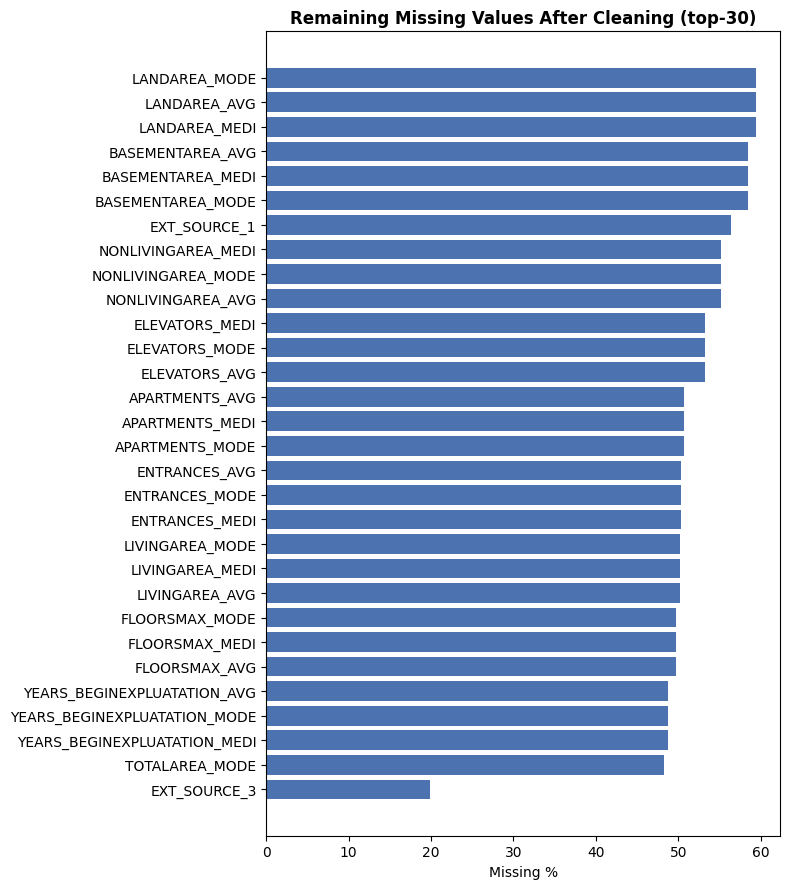


  IMPUTATION STRATEGY (to be applied INSIDE CV folds to avoid leakage):
    - Numerical : median imputation (MedianImputer)
    - Categorical: mode / 'UNKNOWN' fill (already label-encoded as integer)
    - Tree models (XGBoost/LightGBM/CatBoost) handle NaN natively →
      skip explicit imputation for those models.



In [24]:
print("  8. REMAINING MISSING VALUES")

mis_final = missing_report(train, "train after cleaning")

# Quick visualisation of remaining missingness
if len(mis_final) > 0:
    fig, ax = plt.subplots(figsize=(8, max(4, len(mis_final.head(30)) * 0.3)))
    ax.barh(mis_final.head(30).index[::-1],
            mis_final.head(30)["missing_pct"][::-1], color="#4C72B0")
    ax.set_xlabel("Missing %")
    ax.set_title("Remaining Missing Values After Cleaning (top-30)", fontweight="bold")
    save_fig("06_remaining_missing_after_cleaning")

print("""
  IMPUTATION STRATEGY (to be applied INSIDE CV folds to avoid leakage):
    - Numerical : median imputation (MedianImputer)
    - Categorical: mode / 'UNKNOWN' fill (already label-encoded as integer)
    - Tree models (XGBoost/LightGBM/CatBoost) handle NaN natively →
      skip explicit imputation for those models.
""")



In [25]:
# Удалить все колонки о характеристиках здания
building_patterns = [
    "LANDAREA_", "BASEMENTAREA_", "NONLIVINGAREA_", "ELEVATORS_",
    "APARTMENTS_", "ENTRANCES_", "LIVINGAREA_", "FLOORSMAX_",
    "WALLSMATERIAL_", "EMERGENCYSTATE_", "HOUSETYPE_"
]
building_cols = [c for c in train.columns 
                 if any(c.startswith(p) for p in building_patterns)]
train = train.drop(columns=building_cols, errors="ignore")
test  = test.drop(columns=building_cols, errors="ignore")
print(f"  Dropped {len(building_cols)} building-related columns")

  Dropped 27 building-related columns


In [26]:
print("  9. SAVING PROCESSED DATA")

train = reduce_mem_usage(train)
test  = reduce_mem_usage(test)

train_out = OUTPUT_DIR / "train_processed.parquet"
test_out  = OUTPUT_DIR / "test_processed.parquet"
train.to_parquet(train_out, index=False)
test.to_parquet(test_out,   index=False)

print(f"  Saved: {train_out}  ({train.shape})")
print(f"  Saved: {test_out}   ({test.shape})")

  9. SAVING PROCESSED DATA
  Saved: outputs\eda\train_processed.parquet  ((307511, 161))
  Saved: outputs\eda\test_processed.parquet   ((48744, 160))


In [27]:
print("  10. FINAL SUMMARY")

n_num = train.select_dtypes(include=[np.number]).shape[1] - 2  # excl. TARGET + ID
n_cat_encoded = len(cat_cols)

summary = {
    "train_rows"          : len(train),
    "test_rows"           : len(test),
    "total_features"      : train.shape[1] - 2,
    "numeric_features"    : n_num,
    "categorical_encoded" : n_cat_encoded,
    "target_positive_rate": round(train[TARGET].mean(), 4),
    "dropped_high_miss"   : len(drop_cols),
}
for k, v in summary.items():
    print(f"  {k:<28}: {v}")

print("\n Data preparation & EDA complete.")

  10. FINAL SUMMARY
  train_rows                  : 307511
  test_rows                   : 48744
  total_features              : 159
  numeric_features            : 159
  categorical_encoded         : 16
  target_positive_rate        : 0.0807
  dropped_high_miss           : 36

 Data preparation & EDA complete.
